#Loading data + preprocessing

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets

(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
X_train.shape, y_train.shape

((60000, 28, 28), (60000,))

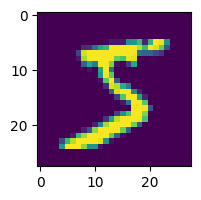

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,2))
plt.imshow(X_train[0])

In [5]:
# Normalize training data
X_train = X_train/255.0
X_test = X_test/255.0

#Building the CNN model

In [10]:
from tensorflow.keras import layers, models
with tf.device('GPU:0'):
  cnn = models.Sequential([
      layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
      layers.MaxPooling2D((2,2)),

      layers.Flatten(),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

  cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8941 - loss: 0.3424
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9842 - loss: 0.0523
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9883 - loss: 0.0373
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9924 - loss: 0.0249
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9941 - loss: 0.0185
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9954 - loss: 0.0145
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9957 - loss: 0.0116
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9976 - loss: 0.0068
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9974 - loss: 0.0076
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9976 - loss: 0.0064


In [11]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9865 - loss: 0.0435


[0.03443731740117073, 0.9907000064849854]

In [12]:
y_pred = cnn.predict(X_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[2.6505617e-11, 4.5327974e-11, 2.7603481e-10, ..., 1.0000000e+00,
        3.5788419e-12, 2.5069924e-09],
       [3.5235287e-14, 7.5520258e-12, 1.0000000e+00, ..., 7.5773284e-17,
        2.1210428e-14, 8.2268465e-15],
       [1.6057150e-09, 1.0000000e+00, 1.6753107e-08, ..., 6.5733585e-10,
        1.3810719e-09, 7.1903082e-12],
       ...,
       [1.3852339e-18, 1.2131511e-13, 1.5942789e-18, ..., 2.0607778e-15,
        1.6642480e-10, 2.1786132e-11],
       [4.4596738e-15, 9.9439279e-17, 2.1743918e-15, ..., 1.1515021e-16,
        3.7781909e-05, 1.2054126e-14],
       [2.1435254e-10, 2.4025467e-12, 1.2741845e-10, ..., 1.8091527e-20,
        2.3337284e-08, 3.2250027e-13]], dtype=float32)

In [13]:
y_pred = [np.argmax(element) for element in y_pred]
y_pred[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [14]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

<Axes: >

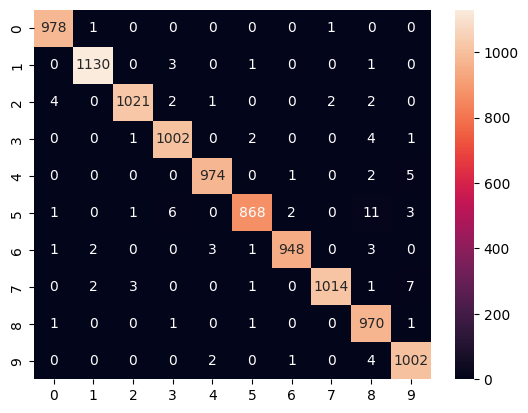

In [16]:
import seaborn as sns
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred)
sns.heatmap(cm, annot=True, fmt='d')

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.97      0.98       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.97      1.00      0.98       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

